**Imports and Model Setup**

In [1]:
import torch
print("PyTorch version:", torch.__version__)  # Should show CUDA version
print("CUDA version in PyTorch:", torch.version.cuda)  # Should match installed CUDA (e.g., 12.1)
print("CUDA available:", torch.cuda.is_available())  # Should return True
print("Number of GPUs:", torch.cuda.device_count())  # Should be > 0
print("GPU Name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU detected")

PyTorch version: 2.5.1+cu121
CUDA version in PyTorch: 12.1
CUDA available: True
Number of GPUs: 1
GPU Name: NVIDIA GeForce RTX 3060


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import random
import tifffile
from PIL import Image
import glob
from pathlib import Path
import timm.models
import timm.layers
import tqdm
import cv2
import torch

c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:

from mobile_sam import sam_model_registry, SamAutomaticMaskGenerator, SamPredictor

model_type = "vit_t"
sam_checkpoint = "weights/mobile_sam.pt"
device = "cpu" # set device to cpu temporarily for dataset transforms

mobile_sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
mobile_sam.to(device=device)

predictor = SamPredictor(mobile_sam)
mask_generator = SamAutomaticMaskGenerator(mobile_sam)

c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\timm\models\layers\__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\timm\models\registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
c:\Users\user\Documents\slurry_viscnet\MobileSAM_Vortex\mobile_sam\modeling\tiny_vit_sam.py:656: UserWarning: Overwriting tiny_vit_5m_224 in registry with mobile_sam.modeling.tiny_vit_sam.tiny_vit_5m_224. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
  return register_model(fn_wrapper)
c:\Users\user\Documents\slurry_viscnet

**Generate Dataset**

In [37]:
#DatasetLoader Definition

import torch
import numpy as np
import cv2
from patchify import patchify
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

class DatasetPreprocessor:
    def __init__(self, image_paths, mask_paths, patch_size=256, step=256, morph_op="opening",
                 radius_erosion=1, iter_erosion=1, radius_dilation=3, iter_dilation=2,
                 batch_size=8, val_split=0.1, test_split=0.1):
        """
        Preprocesses dataset: Applies erosion/dilation, patches images, filters empty masks, 
        extracts bounding boxes, and batches the dataset.

        Args:
            image_paths (list): List of file paths to raw images.
            mask_paths (list): List of file paths to corresponding masks.
            patch_size (int): Size of patches for patchify.
            step (int): Step size for patchify.
            morph_op (str): Type of morphological operation ("opening" or "closing").
            radius_erosion (int): Kernel size for erosion.
            iter_erosion (int): Number of iterations for erosion.
            radius_dilation (int): Kernel size for dilation.
            iter_dilation (int): Number of iterations for dilation.
            batch_size (int): Number of images per batch.
            val_split (float): Fraction of data for validation.
            test_split (float): Fraction of data for testing.
        """
        self.image_paths = sorted(image_paths)
        self.mask_paths = sorted(mask_paths)
        self.patch_size = patch_size
        self.step = step
        self.morph_op = morph_op
        self.radius_erosion = radius_erosion
        self.iter_erosion = iter_erosion
        self.radius_dilation = radius_dilation
        self.iter_dilation = iter_dilation
        self.batch_size = batch_size
        self.val_split = val_split
        self.test_split = test_split

        # Process dataset
        self.processed_data = self._load_and_preprocess_data()
        self.train_set, self.val_set, self.test_set = self._split_dataset()
        self.train_batch, self.val_batch, self.test_batch = self._create_dataloaders()

    def _apply_morphology(self, mask):
        """Applies erosion and dilation to the mask."""
        kernel_erosion = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (self.radius_erosion, self.radius_erosion))
        kernel_dilation = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (self.radius_dilation, self.radius_dilation))

        if self.morph_op == "opening":
            temp = cv2.erode(mask, kernel_erosion, iterations=self.iter_erosion)
            output = cv2.dilate(temp, kernel_dilation, iterations=self.iter_dilation)
        elif self.morph_op == "closing":
            temp = cv2.dilate(mask, kernel_dilation, iterations=self.iter_dilation)
            output = cv2.erode(temp, kernel_erosion, iterations=self.iter_erosion)
        else:
            raise ValueError("Invalid operation. Choose 'opening' or 'closing'.")
        return output

    def _get_bounding_box(self, mask):
        """Extracts bounding box from a mask."""
        y_indices, x_indices = np.where(mask > 0)
    
        x_min, x_max = np.min(x_indices), np.max(x_indices)
        y_min, y_max = np.min(y_indices), np.max(y_indices)

        #add perturbation to box coordinates
        H, W = mask.shape
        x_min = max(0, x_min - np.random.randint(0, 20))
        x_max = min(W, x_max + np.random.randint(0, 20))
        y_min = max(0, y_min - np.random.randint(0, 20))
        y_max = min(H, y_max + np.random.randint(0, 20))

        return np.array([x_min, y_min, x_max, y_max])
        # return np.array([0, 0, 255, 255])

    def _load_and_preprocess_data(self):
        """Loads images, applies preprocessing, patchifies, and filters out empty patches."""
        processed_data = []

        for img_path, mask_path in zip(self.image_paths, self.mask_paths):
            image = cv2.imread(img_path, cv2.IMREAD_COLOR)  # Ensure RGB
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

            # Apply erosion/dilation to the mask
            mask = self._apply_morphology(mask)

            # Patchify
            img_patches = patchify(image, (self.patch_size, self.patch_size, 3), step=self.step)
            mask_patches = patchify(mask, (self.patch_size, self.patch_size), step=self.step)

            for i in range(img_patches.shape[0]):
                for j in range(img_patches.shape[1]):
                    patch_img = img_patches[i, j, 0, :, :, :]
                    patch_mask = mask_patches[i, j, :, :]

                    # Skip empty patches
                    if np.max(patch_mask) == 0:
                        continue

                    # Convert to PyTorch tensors
                    patch_img = torch.tensor(patch_img, dtype=torch.float32).permute(2, 0, 1)
                    patch_mask = torch.tensor(patch_mask, dtype=torch.float32)

                    # Get bounding box
                    bbox = torch.tensor(self._get_bounding_box(patch_mask.numpy()), dtype=torch.float32)

                    processed_data.append({
                        "image": patch_img,
                        "mask": patch_mask,
                        "box": bbox,
                        "original_size": torch.tensor([self.patch_size, self.patch_size], dtype=torch.float32)
                    })
        return processed_data

    def _split_dataset(self):
        """Splits data into training, validation, and test sets."""
        train_size = 1 - (self.val_split + self.test_split)
        train_set, temp_set = train_test_split(self.processed_data, test_size=(1 - train_size), random_state=42)
        val_set, test_set = train_test_split(temp_set, test_size=(self.test_split / (self.val_split + self.test_split)), random_state=42)
        return train_set, val_set, test_set

    def _create_dataloaders(self):
        """Creates DataLoaders for training, validation, and testing."""
        train_batch = DataLoader(self.train_set, batch_size=self.batch_size, shuffle=True, num_workers=4, pin_memory=True)
        val_batch = DataLoader(self.val_set, batch_size=self.batch_size, shuffle=False, num_workers=4, pin_memory=True)
        test_batch = DataLoader(self.test_set, batch_size=self.batch_size, shuffle=False, num_workers=4, pin_memory=True)
        return train_batch, val_batch, test_batch

    def get_dataloaders(self):
        """Returns train, validation, and test DataLoaders."""
        return self.train_batch, self.val_batch, self.test_batch

In [38]:
# Define file paths
image_paths = sorted(glob.glob("captures/raw/raw_*.png"))
mask_paths = sorted(glob.glob("captures/masked/masked_*.png"))

# Initialize preprocessor
preprocessor = DatasetPreprocessor(image_paths, mask_paths, patch_size=256, step=256, batch_size=8) #1132

# Get DataLoaders
train_batch, val_batch, test_batch = preprocessor.get_dataloaders()

import matplotlib.pyplot as plt



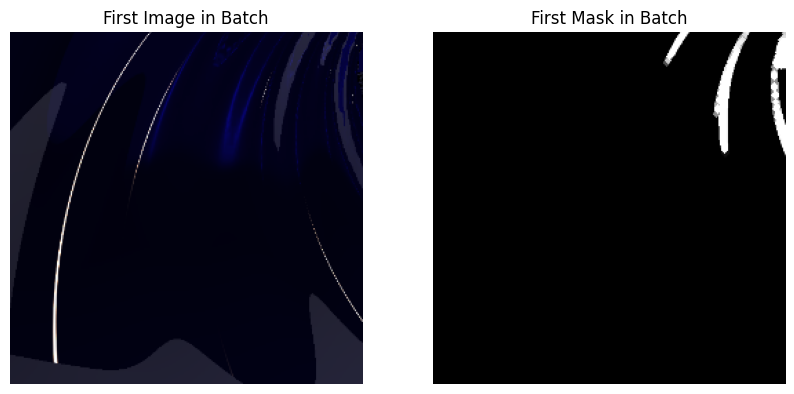

In [43]:
# Data loader test

train_set = preprocessor.train_batch
batch = next(iter(train_set)) #first batch select

idx = 4
# Extract image and mask
first_image = batch["image"][idx].cpu().numpy().transpose(1, 2, 0)  # Convert (C, H, W) → (H, W, C)
first_mask = batch["mask"][idx].cpu().numpy() 

# Plot image and mask
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(first_image.astype(np.uint8))
axes[0].set_title("First Image in Batch")
axes[0].axis("off")

axes[1].imshow(first_mask, cmap="gray")
axes[1].set_title("First Mask in Batch")
axes[1].axis("off")

plt.show()

**Dataset Processor for MobileSAM**

In [41]:
# Save dataset
torch.save(train_batch, './captures/train_batch.pt')
torch.save(val_batch, './captures/val_batch.pt')

**Reset Model for Training**

In [44]:
train_batch = torch.load('./captures/train_batch.pt')
val_batch = torch.load('./captures/val_batch.pt')

C:\Users\user\AppData\Local\Temp\ipykernel_62884\1230091504.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  train_batch = torch.load('./captures/train_batch.pt')
C:\User

In [45]:
from mobile_sam import sam_model_registry, SamPredictor

model_type = "vit_t"
sam_checkpoint = "model/MobileSAM_Vortex_checkpoint.pth"
device = "cuda" if torch.cuda.is_available() else "cpu"

mobile_sam = sam_model_registry["vit_t"](checkpoint="weights/mobile_sam.pt")
mobile_sam.to(device=device)
predictor = SamPredictor(mobile_sam)

c:\Users\user\Documents\slurry_viscnet\MobileSAM_Vortex\mobile_sam\build_sam.py:91: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(f)


In [46]:
# Freeze layers in MobileSAM
for name, param in mobile_sam.named_parameters():
    if name.startswith("image_encoder"):  # Assuming "image_encoder" corresponds to the vision encoder
        param.requires_grad = False  # Freeze the vision encoder
    elif name.startswith("prompt_encoder"):  # Assuming "prompt_encoder" exists in MobileSAM
        param.requires_grad = False  # Freeze the prompt encoder

# Verify trainable parameters
trainable_params = sum(p.numel() for p in mobile_sam.parameters() if p.requires_grad)
print(f"Trainable parameters: {trainable_params}")

# Iterate through all parameters and check their trainable status
print("MobileSAM Parameters:")
for name, param in mobile_sam.named_parameters():
        print(f"{name}: {'Trainable' if param.requires_grad else 'Frozen'}")

# Count the total trainable parameters
trainable_params = sum(p.numel() for p in mobile_sam.parameters() if p.requires_grad)
print(f"\nTotal Trainable Parameters in MobileSAM: {trainable_params}")

Trainable parameters: 4058340
MobileSAM Parameters:
image_encoder.patch_embed.seq.0.c.weight: Frozen
image_encoder.patch_embed.seq.0.bn.weight: Frozen
image_encoder.patch_embed.seq.0.bn.bias: Frozen
image_encoder.patch_embed.seq.2.c.weight: Frozen
image_encoder.patch_embed.seq.2.bn.weight: Frozen
image_encoder.patch_embed.seq.2.bn.bias: Frozen
image_encoder.layers.0.blocks.0.conv1.c.weight: Frozen
image_encoder.layers.0.blocks.0.conv1.bn.weight: Frozen
image_encoder.layers.0.blocks.0.conv1.bn.bias: Frozen
image_encoder.layers.0.blocks.0.conv2.c.weight: Frozen
image_encoder.layers.0.blocks.0.conv2.bn.weight: Frozen
image_encoder.layers.0.blocks.0.conv2.bn.bias: Frozen
image_encoder.layers.0.blocks.0.conv3.c.weight: Frozen
image_encoder.layers.0.blocks.0.conv3.bn.weight: Frozen
image_encoder.layers.0.blocks.0.conv3.bn.bias: Frozen
image_encoder.layers.0.blocks.1.conv1.c.weight: Frozen
image_encoder.layers.0.blocks.1.conv1.bn.weight: Frozen
image_encoder.layers.0.blocks.1.conv1.bn.bias: F

**Training Loop**

In [47]:
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau

# Initialize the optimizer for the mask decoder
optimizer = Adam(mobile_sam.mask_decoder.parameters(), lr=1e-3, weight_decay=0)


from torch import nn
from torch.nn import functional as F


class DiceBCELoss(nn.Module):
    def __init__(self, weight=None, size_average=True):
        super(DiceBCELoss, self).__init__()

    def forward(self, inputs, targets, smooth=1):

        # comment out if your model contains a sigmoid or equivalent activation layer
        inputs = F.sigmoid(inputs)

        # flatten label and prediction tensors
        inputs = inputs.view(-1)
        targets = targets.view(-1)

        intersection = (inputs * targets).sum()
        dice_loss = 1 - (2.0 * intersection + smooth) / (inputs.sum() + targets.sum() + smooth)
        BCE = F.binary_cross_entropy(inputs, targets, reduction="mean")
        Dice_BCE = BCE + dice_loss

        return Dice_BCE


# Define the segmentation loss function
# You can choose between DiceFocalLoss, FocalLoss, or DiceCELoss
seg_loss = DiceBCELoss()

scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3, verbose=True)

c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [48]:
from tqdm import tqdm
from statistics import mean
import torch
import math

# Training loop
num_epochs = 25
device = "cuda" if torch.cuda.is_available() else "cpu"
mobile_sam.to(device)

mobile_sam.train()
for epoch in range(num_epochs):
    train_losses = []
    for batch_group in tqdm(train_batch, desc=f"Epoch {epoch+1}/{num_epochs} - Training"):
        #stacking mask/training model/mask retrieve
        mask_batch = torch.stack([sample["ground_truth_mask"].unsqueeze(0).to(device) for sample in batch_group]) # 8 masked images rgb
        outputs = mobile_sam(batched_input = batch_group, multimask_output = False) #requires the whole batch
        predicted_masks = torch.stack([output["masks"].squeeze(1).float() for output in outputs])

        #loss calculation/optimization
        train_loss = seg_loss(predicted_masks, mask_batch)
        train_losses.append(train_loss.item())
        optimizer.zero_grad()
        train_loss.backward()
        optimizer.step()

        if (len(train_losses)) % 100 == 0:
            print(f'Batch {len(train_losses)+1}/{len(train_batch)} - Training Loss: {train_loss.item():.2f}')

    mean_train_loss = mean(train_losses)
    train_losses.clear()

    # Validation loss calculation
    mobile_sam.eval()
    val_losses = []
    with torch.no_grad():
        for batch_group in tqdm(val_batch, desc=f"Epoch {epoch+1}/{num_epochs} - Validation"):
            mask_batch = torch.stack([sample["ground_truth_mask"].unsqueeze(0).to(device) for sample in batch_group])
            outputs = mobile_sam(batched_input=batch_group, multimask_output=False)
            predicted_masks = torch.stack([output["masks"].squeeze(1).float() for output in outputs])
            val_loss = seg_loss(predicted_masks, mask_batch)
            val_losses.append(val_loss.item())
    mean_val_loss = mean(val_losses)
     
    print(f'EPOCH: {epoch + 1}/{num_epochs} - Train Loss: {mean_train_loss:.4f} | Val Loss: {mean_val_loss:.4f}')
    scheduler.step(val_loss)
    mobile_sam.train()


Epoch 1/25 - Training:   0%|          | 0/1724 [00:21<?, ?it/s]


KeyboardInterrupt: 

In [ ]:
# Save the state_dict after moving layers
torch.save(mobile_sam.state_dict(), "model/MobileSAM_Vortex_checkpoint.pth")

**Inference**

In [ ]:
from mobile_sam import sam_model_registry, SamPredictor

vortex_model = sam_model_registry["vit_t"](checkpoint="model/MobileSAM_Vortex_checkpoint.pth")
vortex_model.eval()
predictor = SamPredictor(vortex_model)

In [ ]:
import random
test_number = 3

for i in range(test_number):
    idx = random.randint(0,len(test_images)-1)
    
    test_image = test_images[idx].cpu().numpy()
    test_image = np.transpose(test_image, (1,2,0))
    test_box = test_boxes[idx].cpu().numpy()
    test_mask = test_masks[idx].cpu().numpy()

    predictor.set_image(test_image)
    masks, _, _ = predictor.predict(box = test_box, return_logits=True)
    
    masks = np.transpose(masks,(1,2,0))
    masks = masks.astype(np.uint8)
    fig, axes = plt.subplots(1,3,figsize=(15,5))

    axes[0].imshow(test_image)
    axes[0].set_title("Original Image")

    axes[1].imshow(test_mask, cmap='gray')
    axes[1].set_title("Ground Truth Mask")

    axes[2].imshow(masks)
    axes[2].set_title("Inference Output")

    for ax in axes:
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_xticklabels([])
        ax.set_yticklabels([])

    plt.show()


In [ ]:
torch.cuda.empty_cache()